# K-Means Clustering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-unsupervised-learning/k-means/notes.ipynb)

**Module:** Unsupervised Learning
**Status:** demo / work in progress — theory below is a placeholder structure. Swap in your class notes + links here.


## 1. Theory

**What it is:** K-Means is an unsupervised clustering algorithm that partitions `n` data points into `k` clusters,
where each point belongs to the cluster with the nearest mean (centroid).

**Objective:** minimize the within-cluster sum of squares (WCSS / inertia):

$$
J = \sum_{i=1}^{k} \sum_{x \in C_i} \lVert x - \mu_i \rVert^2
$$

where $\mu_i$ is the centroid of cluster $C_i$.

**Algorithm (Lloyd's algorithm):**
1. Choose `k` and initialize `k` centroids (randomly, or via `k-means++`).
2. **Assign step:** assign every point to its nearest centroid.
3. **Update step:** recompute each centroid as the mean of points assigned to it.
4. Repeat 2–3 until assignments stop changing (convergence) or max iterations reached.

**Choosing k:**
- **Elbow method** — plot inertia vs. k, look for the "elbow" where gains flatten.
- **Silhouette score** — measures how well-separated clusters are (higher is better, range -1 to 1).

**Caveats:**
- Sensitive to initial centroid placement → use `k-means++` (sklearn default) or multiple random restarts (`n_init`).
- Assumes roughly spherical, similarly-sized clusters — struggles with irregular shapes (DBSCAN handles that better).
- Sensitive to feature scale — always standardize features first.

> 📝 **Your notes go here:** paste class-note summaries, links, and any diagrams your instructor used. This cell is
> just a structural placeholder to prove out the format.


## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (6, 5)
np.random.seed(42)

## 3. Generate sample data
Synthetic blobs so we can *see* clustering behave (swap for a real dataset later).

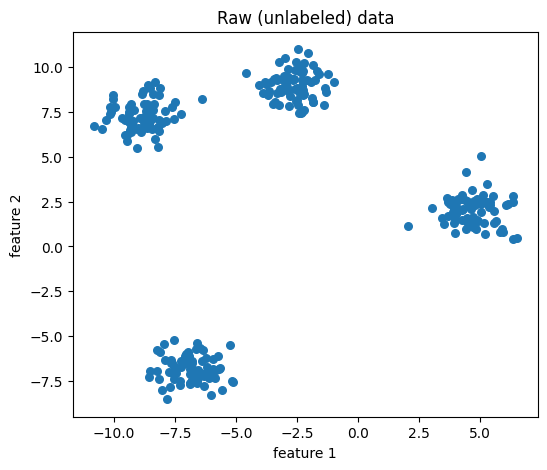

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.80, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Raw (unlabeled) data")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()

## 4. From-scratch implementation

Implementing it manually first builds intuition for the assign/update loop before relying on `scikit-learn`.


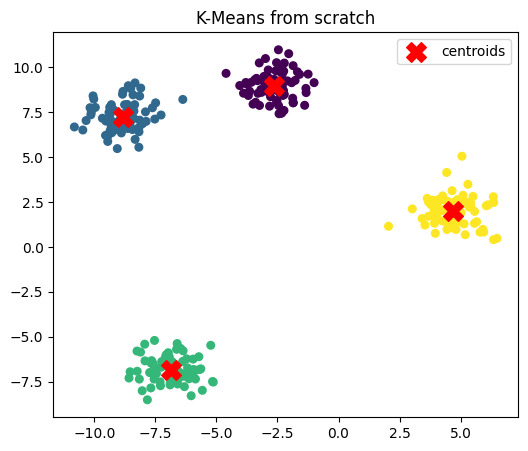

In [3]:
def kmeans_from_scratch(X, k, n_iters=100, seed=42):
    rng = np.random.default_rng(seed)
    # init: pick k random points as starting centroids
    centroids = X[rng.choice(len(X), k, replace=False)]

    for _ in range(n_iters):
        # assign step: distance from every point to every centroid
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)

        # update step: recompute centroids as mean of assigned points
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])

        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    return labels, centroids

labels_scratch, centroids_scratch = kmeans_from_scratch(X, k=4)

plt.scatter(X[:, 0], X[:, 1], c=labels_scratch, cmap="viridis", s=30)
plt.scatter(centroids_scratch[:, 0], centroids_scratch[:, 1], c="red", marker="X", s=200, label="centroids")
plt.title("K-Means from scratch")
plt.legend()
plt.show()

## 5. scikit-learn version
Same idea, production-ready implementation (k-means++ init, multiple restarts).

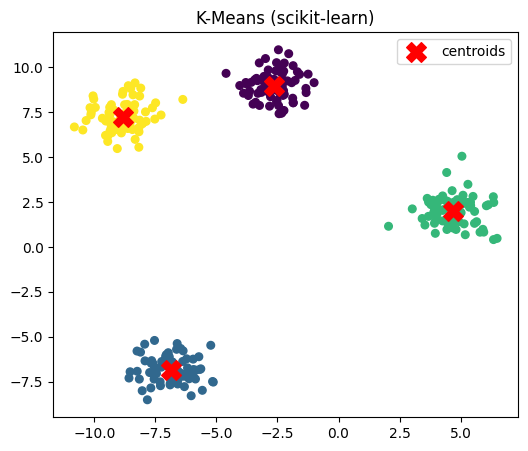

In [4]:
kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)
labels_sklearn = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, cmap="viridis", s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="centroids")
plt.title("K-Means (scikit-learn)")
plt.legend()
plt.show()

## 6. Choosing k — Elbow method

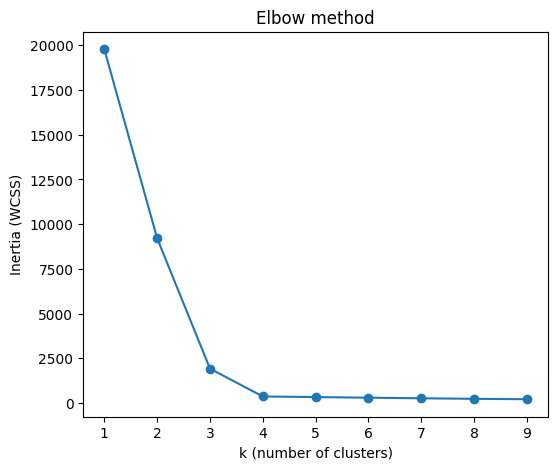

In [5]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow method")
plt.show()

## 7. Choosing k — Silhouette score

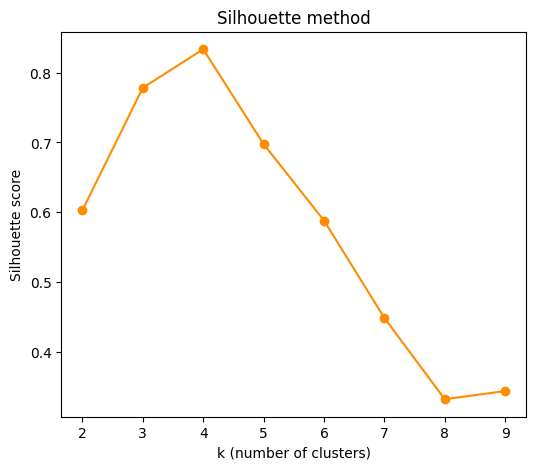

In [6]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range2 = range(2, 10)
for k in k_range2:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sil_scores.append(silhouette_score(X, km.labels_))

plt.plot(list(k_range2), sil_scores, marker="o", color="darkorange")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette method")
plt.show()

## 8. Takeaways

- K-Means converges to a *local* optimum — initialization matters, hence `k-means++` / `n_init`.
- Elbow + silhouette are heuristics, not guarantees — combine with domain knowledge about how many groups
  actually make sense.
- Always scale features before clustering (`StandardScaler`) when features are on different scales.

**Next up:** Hierarchical Clustering, DBSCAN, PCA.
